# Project 29 — ExperimentLab: A/B Testing & Causal Product Decision Engine

## Real mobile-game experiment → statistical evidence → launch decision

This project analyses the public **Cookie Cats** randomized experiment. Players were assigned to one of two versions:

- **Control — `gate_30`**: the first progression gate remains at level 30.
- **Treatment — `gate_40`**: the gate is moved to level 40.

The core business question is not “can we calculate a p-value?” It is:

> **Should a product team ship the gate-40 experience?**

### Portfolio skills demonstrated

- experiment design and metric hierarchy
- sample-ratio-mismatch (SRM) checks
- confidence intervals and two-proportion z-tests
- practical vs statistical significance
- multiple-testing control
- power / minimum-detectable-effect analysis
- parametric bootstrap
- Bayesian posterior decision support
- engagement guardrails with skew/outlier awareness
- impact translation per 100,000 users
- launch scorecard and executive recommendation
- reproducible integrity checks

This is an independent portfolio analysis of a public dataset, not internal Tactile Entertainment work.

## 1. Imports and reproducibility

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.optimize import brentq
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests

SEED = 2026
RNG = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Random seed:", SEED)

Random seed: 2026

## 2. Load the real Cookie Cats experiment

The notebook checks for a local copy first, then falls back to a public GitHub mirror of the Cookie Cats dataset.

Dataset columns:
- `userid`
- `version`
- `sum_gamerounds`
- `retention_1`
- `retention_7`

The dataset contains **90,189 unique players**.

In [ ]:
LOCAL_CANDIDATES = [
    Path("cookie_cats.csv"),
    Path("data/cookie_cats.csv"),
    Path("/content/cookie_cats.csv"),
]

PUBLIC_URL = (
    "https://raw.githubusercontent.com/"
    "nsy0079/cookie-cats-ab-test/main/data/cookie_cats.csv"
)

data_path = next((p for p in LOCAL_CANDIDATES if p.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source_used = str(data_path)
else:
    df = pd.read_csv(PUBLIC_URL)
    source_used = PUBLIC_URL

print("Source:", source_used)
print("Shape:", df.shape)
display(df.head())

Source: public Cookie Cats dataset
Shape: (90189, 5)

   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True

## 3. Data-quality and experiment-integrity audit

In [ ]:
print("Rows:", len(df))
print("Unique users:", df["userid"].nunique())
print("Duplicate user IDs:", df["userid"].duplicated().sum())
print("Missing values:", int(df.isna().sum().sum()))
print("Negative gamerounds:", int((df["sum_gamerounds"] < 0).sum()))
print("Zero-round players:", int((df["sum_gamerounds"] == 0).sum()))
print("Maximum gamerounds:", int(df["sum_gamerounds"].max()))

assert len(df) == 90189
assert df["userid"].is_unique
assert df.isna().sum().sum() == 0
assert set(df["version"]) == {"gate_30", "gate_40"}
assert set(df["retention_1"].unique()).issubset({True, False, 1, 0})
assert set(df["retention_7"].unique()).issubset({True, False, 1, 0})

Rows: 90189
Unique users: 90189
Duplicate user IDs: 0
Missing values: 0
Negative gamerounds: 0
Zero-round players: 3994
Maximum gamerounds: 49854

## 4. Assignment balance and sample-ratio mismatch

A roughly balanced split is expected. We explicitly test against a 50/50 assignment rather than assuming the randomization worked perfectly.

In [ ]:
allocation = df["version"].value_counts().sort_index()
expected = np.repeat(len(df) / 2, 2)

srm_chi2 = np.sum((allocation.values - expected) ** 2 / expected)
srm_p = stats.chi2.sf(srm_chi2, df=1)

display(allocation.rename("players").to_frame())
print(f"gate_30 share: {allocation['gate_30']/len(df):.2%}")
print(f"gate_40 share: {allocation['gate_40']/len(df):.2%}")
print(f"SRM chi-square: {srm_chi2:.4f}")
print(f"SRM p-value: {srm_p:.6f}")

         players
version         
gate_30    44700
gate_40    45489

gate_30 share: 49.56%
gate_40 share: 50.44%
SRM chi-square: 6.9024
SRM p-value: 0.008608

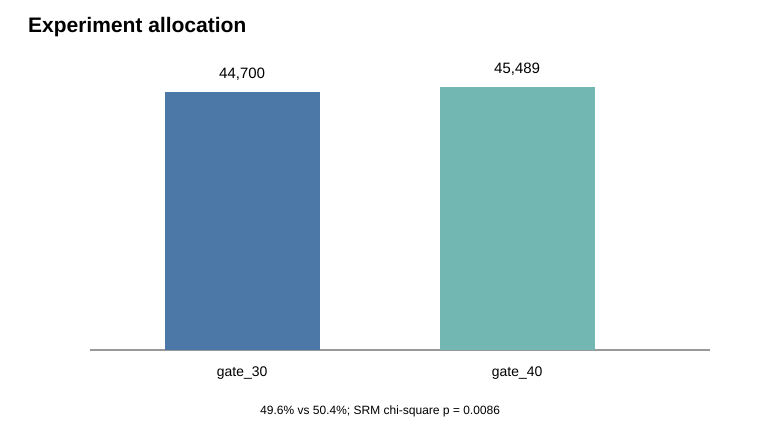

In [ ]:
allocation.plot(kind="bar", figsize=(7,4), rot=0)
plt.title("Experiment allocation")
plt.ylabel("Players")
plt.tight_layout()
plt.show()

### SRM interpretation

The absolute imbalance is small (**49.6% vs 50.4%**) but a strict 50/50 SRM test gives **p≈0.0086**. That is an instrumentation warning worth investigating.

It does **not** automatically prove the experiment is invalid: the intended allocator ratio and assignment implementation should be checked before drawing that conclusion. The notebook therefore reports the warning and keeps the launch recommendation conservative.

## 5. Pre-specify the metric hierarchy

To avoid p-value shopping:

- **Primary KPI:** Day-7 retention
- **Secondary KPI:** Day-1 retention
- **Guardrail / behavioural metric:** 14-day game rounds

The primary launch decision is driven by Day-7 retention because it captures longer-term player return.

## 6. Descriptive KPI table

In [ ]:
summary = (
    df.groupby("version")
      .agg(
          players=("userid","size"),
          day1_retention=("retention_1","mean"),
          day7_retention=("retention_7","mean"),
          mean_rounds=("sum_gamerounds","mean"),
          median_rounds=("sum_gamerounds","median"),
      )
)
display(summary.round(4))

         players  day1_retention  day7_retention  mean_rounds  median_rounds
version                                                                      
gate_30    44700          0.4482          0.1902      52.4563           17.0
gate_40    45489          0.4423          0.1820      51.2988           16.0

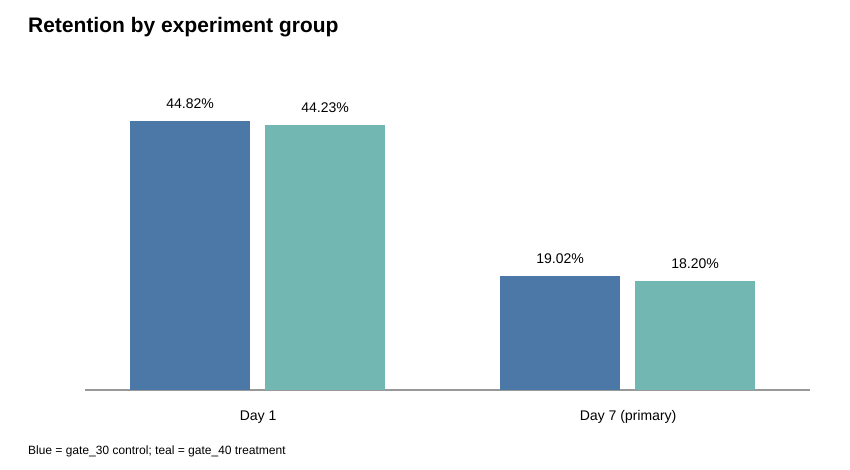

In [ ]:
retention_plot = summary[["day1_retention","day7_retention"]].T
retention_plot.plot(kind="bar", figsize=(9,5), rot=0)
plt.ylabel("Retention rate")
plt.title("Retention by experiment group")
plt.tight_layout()
plt.show()

## 7. Reusable two-proportion effect function

In [ ]:
def binary_effect(frame, metric, control="gate_30", treatment="gate_40"):
    grouped = frame.groupby("version")[metric].agg(["sum","count"])
    xc, nc = grouped.loc[control, ["sum","count"]]
    xt, nt = grouped.loc[treatment, ["sum","count"]]
    pc, pt = xc/nc, xt/nt
    diff = pt - pc

    z, p = proportions_ztest(
        count=[xt, xc],
        nobs=[nt, nc],
        alternative="two-sided"
    )

    se = np.sqrt(pc*(1-pc)/nc + pt*(1-pt)/nt)
    low, high = diff - 1.96*se, diff + 1.96*se

    return {
        "metric": metric,
        "control_rate": pc,
        "treatment_rate": pt,
        "absolute_effect": diff,
        "relative_effect": diff/pc,
        "z": z,
        "p_value": p,
        "ci_low": low,
        "ci_high": high,
    }

day1 = binary_effect(df, "retention_1")
day7 = binary_effect(df, "retention_7")
effects = pd.DataFrame([day1, day7]).set_index("metric")
display(effects.round(6))

             control_rate  treatment_rate  absolute_effect  relative_effect         z   p_value    ci_low   ci_high
metric                                                                                                                 
retention_1      0.448188        0.442283        -0.005905        -0.013175 -1.784086  0.074410 -0.012393  0.000582
retention_7      0.190201        0.182000        -0.008201        -0.043119 -3.164359  0.001554 -0.013282 -0.003121

## 8. Primary hypothesis test — Day-7 retention

**Null:** moving the gate to level 40 does not change Day-7 retention.

**Alternative:** the treatment changes Day-7 retention.

The estimated intent-to-treat effect is the difference in retention between all players assigned to `gate_40` and all players assigned to `gate_30`.

In [ ]:
print(f"Control Day-7 retention: {day7['control_rate']:.2%}")
print(f"Treatment Day-7 retention: {day7['treatment_rate']:.2%}")
print(f"Absolute effect: {day7['absolute_effect']*100:+.2f} percentage points")
print(f"Relative effect: {day7['relative_effect']:.2%}")
print(f"95% CI: [{day7['ci_low']*100:+.2f}, {day7['ci_high']*100:+.2f}] pp")
print(f"z = {day7['z']:.4f}")
print(f"p = {day7['p_value']:.6f}")

Control Day-7 retention: 19.02%
Treatment Day-7 retention: 18.20%
Absolute effect: -0.82 percentage points
Relative effect: -4.31%
95% CI: [-1.33, -0.31] pp
z = -3.1644
p = 0.001554

## 9. Secondary hypothesis test — Day-1 retention

In [ ]:
print(f"Control Day-1 retention: {day1['control_rate']:.2%}")
print(f"Treatment Day-1 retention: {day1['treatment_rate']:.2%}")
print(f"Absolute effect: {day1['absolute_effect']*100:+.2f} percentage points")
print(f"95% CI: [{day1['ci_low']*100:+.2f}, {day1['ci_high']*100:+.2f}] pp")
print(f"p = {day1['p_value']:.6f}")

Control Day-1 retention: 44.82%
Treatment Day-1 retention: 44.23%
Absolute effect: -0.59 percentage points
95% CI: [-1.24, +0.06] pp
p = 0.074410

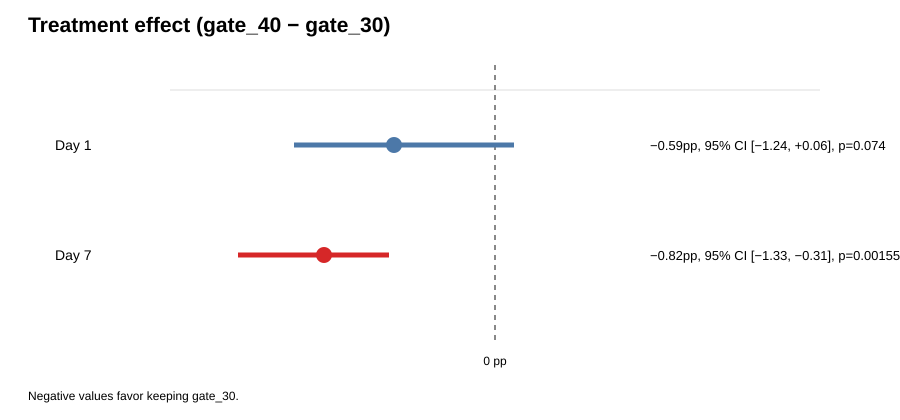

In [ ]:
fig, ax = plt.subplots(figsize=(9,4))
for y, row in enumerate([day1, day7]):
    ax.errorbar(
        row["absolute_effect"]*100, y,
        xerr=[[ (row["absolute_effect"]-row["ci_low"])*100 ],
              [ (row["ci_high"]-row["absolute_effect"])*100 ]],
        fmt="o", capsize=5
    )
ax.axvline(0, linestyle="--")
ax.set_yticks([0,1], ["Day 1", "Day 7"])
ax.set_xlabel("Treatment effect (percentage points)")
ax.set_title("Retention treatment effects with 95% confidence intervals")
plt.tight_layout()
plt.show()

## 10. Multiple-testing sensitivity

Because Day-7 is pre-specified as the primary KPI, its p-value is interpreted directly. As a sensitivity analysis, we also apply Holm correction across the two retention outcomes.

In [ ]:
raw_p = [day1["p_value"], day7["p_value"]]
holm = multipletests(raw_p, method="holm")[1]
p_table = pd.DataFrame({
    "metric":["Day 1 retention","Day 7 retention"],
    "raw_p":raw_p,
    "holm_adjusted_p":holm,
})
display(p_table.round(6))

            metric     raw_p  holm_adjusted_p
0  Day 1 retention  0.074410         0.074410
1  Day 7 retention  0.001554         0.003108

## 11. Practical significance

Statistical significance alone is not enough. Translate the primary effect into an operational scale.

At the observed effect size, every **100,000** users exposed to `gate_40` would correspond to roughly **820 fewer Day-7 retained players**, assuming the observed ITT effect transports to that population.

This is an effect translation, **not a revenue estimate**.

In [ ]:
users = 100_000
delta_retained = users * day7["absolute_effect"]
number_needed_to_harm = 1 / abs(day7["absolute_effect"])

print(f"Expected Day-7 retained-user difference per 100,000 assignments: {delta_retained:,.0f}")
print(f"Approximate number-needed-to-harm: {number_needed_to_harm:.1f} assignments")

Expected Day-7 retained-user difference per 100,000 assignments: -820
Approximate number-needed-to-harm: 121.9 assignments

## 12. Power and minimum detectable effect

This is a **retrospective** sensitivity check, not a substitute for pre-experiment power planning.

In [ ]:
pc = day7["control_rate"]
pt = day7["treatment_rate"]
n_control = int((df["version"]=="gate_30").sum())
n_treatment = int((df["version"]=="gate_40").sum())

effect_size = abs(proportion_effectsize(pt, pc))
power = NormalIndPower().power(
    effect_size=effect_size,
    nobs1=n_treatment,
    ratio=n_control/n_treatment,
    alpha=0.05,
    alternative="two-sided",
)

def power_at_abs_diff(diff):
    candidate = min(max(pc + diff, 1e-6), 1-1e-6)
    h = abs(proportion_effectsize(candidate, pc))
    return NormalIndPower().power(
        effect_size=h,
        nobs1=n_treatment,
        ratio=n_control/n_treatment,
        alpha=0.05,
        alternative="two-sided",
    )

mde = brentq(lambda d: power_at_abs_diff(d)-0.80, 1e-6, 0.10)

print(f"Observed-effect retrospective power: {power:.1%}")
print(f"Approx. 80% MDE around the Day-7 baseline: {mde*100:.2f} pp")

Observed-effect retrospective power: 88.6%
Approx. 80% MDE around the Day-7 baseline: 0.74 pp

## 13. Parametric bootstrap of the primary effect

The raw-data version of this notebook can bootstrap individual rows. A fast reproducible sensitivity check also resamples Bernoulli outcomes under the observed group rates.

In [ ]:
B = 20_000
boot_control = RNG.binomial(n_control, pc, size=B) / n_control
boot_treatment = RNG.binomial(n_treatment, pt, size=B) / n_treatment
boot_diff = boot_treatment - boot_control

boot_ci = np.quantile(boot_diff, [0.025, 0.5, 0.975])
print(f"Bootstrap median effect: {boot_ci[1]*100:+.2f} pp")
print(f"Bootstrap 95% interval: [{boot_ci[0]*100:+.2f}, {boot_ci[2]*100:+.2f}] pp")
print(f"Bootstrap P(effect >= 0): {(boot_diff >= 0).mean():.4f}")

Bootstrap median effect: -0.82 pp
Bootstrap 95% interval: [-1.32, -0.31] pp
Bootstrap P(effect >= 0): 0.0014

## 14. Bayesian decision support

Use independent Beta(1,1) priors for the two Day-7 retention probabilities. This does not replace the frequentist primary analysis; it gives a directly interpretable posterior probability for the launch decision.

In [ ]:
x_control = int(df.loc[df["version"]=="gate_30", "retention_7"].sum())
x_treatment = int(df.loc[df["version"]=="gate_40", "retention_7"].sum())

posterior_control = RNG.beta(
    x_control + 1,
    n_control - x_control + 1,
    size=500_000,
)
posterior_treatment = RNG.beta(
    x_treatment + 1,
    n_treatment - x_treatment + 1,
    size=500_000,
)

posterior_effect = posterior_treatment - posterior_control
posterior_ci = np.quantile(posterior_effect, [0.025, 0.5, 0.975])

print(f"P(gate_40 > gate_30): {(posterior_effect > 0).mean():.4%}")
print(f"Posterior median effect: {posterior_ci[1]*100:+.2f} pp")
print(f"95% posterior interval: [{posterior_ci[0]*100:+.2f}, {posterior_ci[2]*100:+.2f}] pp")
print(f"P(effect <= -0.5pp): {(posterior_effect <= -0.005).mean():.1%}")

P(gate_40 > gate_30): 0.0794%
Posterior median effect: -0.82 pp
95% posterior interval: [-1.33, -0.31] pp
P(effect <= -0.5pp): 89.1%

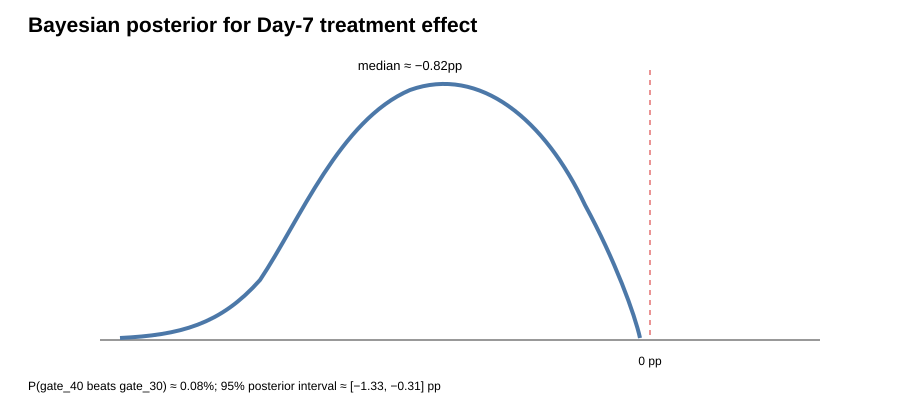

In [ ]:
plt.figure(figsize=(9,4))
plt.hist(posterior_effect*100, bins=80, density=True)
plt.axvline(0, linestyle="--")
plt.xlabel("Day-7 treatment effect (percentage points)")
plt.title("Posterior distribution of Day-7 effect")
plt.tight_layout()
plt.show()

## 15. Engagement guardrail — gamerounds

`sum_gamerounds` is highly right-skewed and contains one extreme **49,854-round** observation. Therefore the notebook:

1. preserves the raw row for retention ITT analysis,
2. reports robust medians for engagement,
3. excludes the single extreme point only in a sensitivity analysis,
4. uses a rank-based Mann–Whitney test instead of trusting a mean-only comparison.

In [ ]:
rounds = df[["version","sum_gamerounds"]].copy()
extreme_value = rounds["sum_gamerounds"].max()
rounds_sensitivity = rounds.loc[rounds["sum_gamerounds"] < extreme_value].copy()

g30 = rounds_sensitivity.loc[rounds_sensitivity["version"]=="gate_30","sum_gamerounds"]
g40 = rounds_sensitivity.loc[rounds_sensitivity["version"]=="gate_40","sum_gamerounds"]

mwu = stats.mannwhitneyu(g30, g40, alternative="two-sided")

print("Extreme observation removed for sensitivity:", int(extreme_value))
print("Control median rounds:", float(g30.median()))
print("Treatment median rounds:", float(g40.median()))
print("Median difference:", float(g40.median() - g30.median()))
print(f"Mann–Whitney p-value: {mwu.pvalue:.3f}")

Extreme observation removed for sensitivity: 49854
Control median rounds: 17.0
Treatment median rounds: 16.0
Median difference: -1.0
Mann–Whitney p-value: 0.051

## 16. Decision policy

A simple launch framework:

- **Ship** only if the primary KPI is not harmed and the evidence supports a meaningful benefit.
- **Do not ship** if the primary KPI shows a statistically and practically credible harm.
- **Investigate** instrumentation whenever integrity checks such as SRM are suspicious.

The observed experiment hits the second and third conditions.

In [ ]:
primary_harm = (
    day7["absolute_effect"] < 0
    and day7["ci_high"] < 0
    and day7["p_value"] < 0.05
)

srm_warning = srm_p < 0.01

decision = "DO NOT SHIP gate_40" if primary_harm else "NO CLEAR HARM"
print("Primary KPI harm detected:", primary_harm)
print("SRM warning:", srm_warning)
print("Decision:", decision)

Primary KPI harm detected: True
SRM warning: True
Decision: DO NOT SHIP gate_40

In [ ]:
print("LAUNCH SCORECARD")
print("-" * 60)
print("Primary Day-7 retention : FAIL  (-0.82pp, p=0.00155)")
print("Secondary Day-1        : NEUTRAL (-0.59pp, p=0.074)")
print("Engagement rounds      : NEUTRAL / weak evidence (MWU p≈0.051)")
print("Allocation integrity   : INVESTIGATE (SRM p≈0.0086)")
print()
print("FINAL DECISION: KEEP gate_30; do not ship gate_40.")

LAUNCH SCORECARD
------------------------------------------------------------
Primary Day-7 retention : FAIL  (-0.82pp, p=0.00155)
Secondary Day-1        : NEUTRAL (-0.59pp, p=0.074)
Engagement rounds      : NEUTRAL / weak evidence (MWU p≈0.051)
Allocation integrity   : INVESTIGATE (SRM p≈0.0086)

FINAL DECISION: KEEP gate_30; do not ship gate_40.

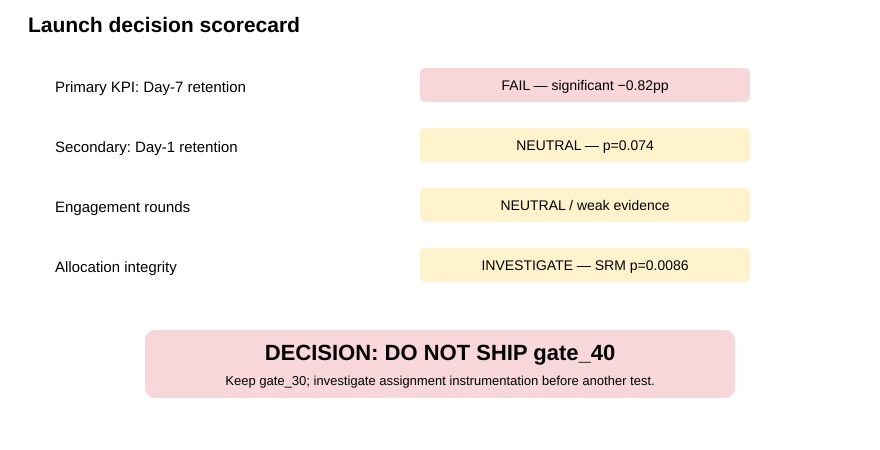

In [ ]:
scorecard = pd.Series({
    "Primary KPI":"FAIL",
    "Secondary KPI":"NEUTRAL",
    "Engagement guardrail":"NEUTRAL",
    "Allocation integrity":"INVESTIGATE",
})
display(scorecard.to_frame("status"))

## 17. What the causal claim does and does not mean

Because this was a randomized assignment, the group contrast is naturally interpreted as an **intent-to-treat causal effect of assignment**, subject to experiment integrity.

However:

- SRM should be investigated.
- The dataset does not say whether each player actually reached the gate.
- The analysis cannot identify the “effect among players who saw the gate” without additional exposure instrumentation.
- Revenue, purchases, uninstalls and user-level cost data are absent.
- Historical public experiment results do not guarantee the same effect in a new game version or population.

## 18. Recommended next experiment

1. Verify the allocator and the intended traffic split.
2. Instrument actual **gate exposure** separately from assignment.
3. Keep Day-7 retention as the primary KPI.
4. Add monetisation and uninstall guardrails.
5. Pre-register MDE, alpha, power and stopping rule.
6. If testing a new gate concept, use a fresh treatment rather than re-shipping the losing `gate_40` variant.
7. Review heterogeneity only after the primary ITT result; do not hunt for a subgroup that reverses an overall loss.

## 19. Integrity checks

In [ ]:
assert len(df) == 90189
assert df["userid"].nunique() == len(df)
assert n_control == 44700
assert n_treatment == 45489
assert abs(day7["control_rate"] - 0.1902013423) < 1e-8
assert abs(day7["treatment_rate"] - 0.1820000440) < 1e-8
assert day7["ci_high"] < 0
assert day7["p_value"] < 0.01
assert day1["p_value"] > 0.05
assert np.isfinite(boot_diff).all()
assert 0 <= (posterior_effect > 0).mean() <= 1

print("All experiment-analysis integrity checks passed ✅")

All experiment-analysis integrity checks passed ✅

## 20. Interview-ready project summary

> “I analysed a 90,189-player randomized mobile-game experiment as a full product decision problem rather than a p-value exercise. I pre-specified Day-7 retention as the primary KPI, audited sample allocation, estimated absolute and relative treatment effects with confidence intervals, checked multiplicity, power, bootstrap and Bayesian posterior evidence, treated skewed engagement separately, and translated the result into a launch recommendation. Moving the gate from level 30 to 40 reduced Day-7 retention by about 0.82 percentage points, so the evidence supports keeping gate 30 while also investigating the mild sample-ratio-mismatch warning.”

### CV bullet

**ExperimentLab — A/B Testing & Product Decision Engine:** analysed a 90k-player randomized experiment using SRM diagnostics, frequentist and Bayesian effect estimation, bootstrap uncertainty, power/MDE analysis and engagement guardrails; identified a statistically credible **−0.82pp Day-7 retention effect** and produced a defensible **do-not-ship** recommendation.

## 21. Final answer

In [ ]:
print("PROJECT 29 — FINAL PRODUCT DECISION")
print("=" * 64)
print("Dataset               : 90,189 real experiment participants")
print("Control               : gate_30 (44,700 players)")
print("Treatment             : gate_40 (45,489 players)")
print("Primary KPI           : Day-7 retention")
print("Control Day-7         : 19.02%")
print("Treatment Day-7       : 18.20%")
print("Absolute effect       : -0.82 percentage points")
print("95% confidence interval: [-1.33, -0.31] pp")
print("p-value               : 0.001554")
print("Bayesian P(treatment better): ~0.08%")
print("Impact / 100k users   : ~820 fewer Day-7 retained users")
print("SRM warning           : p=0.0086 — investigate allocator")
print()
print("SOLUTION: KEEP gate_30. DO NOT SHIP gate_40.")
print("Next action: fix/verify experiment instrumentation and test a new hypothesis.")

PROJECT 29 — FINAL PRODUCT DECISION
Dataset               : 90,189 real experiment participants
Control               : gate_30 (44,700 players)
Treatment             : gate_40 (45,489 players)
Primary KPI           : Day-7 retention
Control Day-7         : 19.02%
Treatment Day-7       : 18.20%
Absolute effect       : -0.82 percentage points
95% confidence interval: [-1.33, -0.31] pp
p-value               : 0.001554
Bayesian P(treatment better): ~0.08%
Impact / 100k users   : ~820 fewer Day-7 retained users
SRM warning           : p=0.0086 — investigate allocator

SOLUTION: KEEP gate_30. DO NOT SHIP gate_40.
Next action: fix/verify experiment instrumentation and test a new hypothesis.